In [1]:
# === Cellule 1 : Imports et configuration ===

import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

import openslide
import cv2  # important pour Laplacien + HSV

# Chemins d'entrée (Kaggle)
NORMAL_ROOT = "/kaggle/input/camelyon-normal6"
TUMOR_ROOT  = "/kaggle/input/camelyon-tumor4"

# Chemins de sortie
PATCH_DIR   = "/kaggle/working/patches"           # où stocker les patchs .png
CSV_PATH    = "/kaggle/working/patches_metadata.csv"

os.makedirs(PATCH_DIR, exist_ok=True)

# Paramètres de tiling
PATCH_SIZE = 256
STRIDE     = 256            # tu peux passer à 512 pour aller plus vite
MAX_PATCHES_PER_WSI = 300   # max de patchs gardés par WSI


In [2]:
# === Cellule 2 : trouver les fichiers .tif / .tiff ===

def find_tif_slides(root_dir):
    slides = []
    for r, d, f in os.walk(root_dir):
        for name in f:
            if name.lower().endswith((".tif", ".tiff")):
                slides.append(os.path.join(r, name))
    return sorted(slides)

normal_slides = find_tif_slides(NORMAL_ROOT)
tumor_slides  = find_tif_slides(TUMOR_ROOT)

print("WSI normales  :", len(normal_slides))
print("WSI tumorales :", len(tumor_slides))

print("\nExemple WSI normale :", normal_slides[0] if len(normal_slides) > 0 else "aucune")
print("Exemple WSI tumorale:", tumor_slides[0] if len(tumor_slides) > 0 else "aucune")


WSI normales  : 24
WSI tumorales : 32

Exemple WSI normale : /kaggle/input/camelyon-normal6/normal_074.tif
Exemple WSI tumorale: /kaggle/input/camelyon-tumor4/tumor_025.tif


In [3]:
# === Cellule 3 : gestion des checkpoints ===

records = []

if os.path.exists(CSV_PATH):
    # On reprend là où on s'est arrêté
    df_existing = pd.read_csv(CSV_PATH)
    records = df_existing.to_dict(orient="records")
    done_wsi_ids = set(df_existing["wsi_id"].unique())
    print(f"Checkpoint détecté : {len(done_wsi_ids)} WSI déjà traitées, {len(records)} patchs déjà enregistrés.")
else:
    df_existing = None
    done_wsi_ids = set()
    print("Pas de checkpoint trouvé : on part de zéro.")


Pas de checkpoint trouvé : on part de zéro.


In [4]:
# === Cellule 4 : filtres qualité sur les patchs ===

def is_tissue(img,
              white_thresh=0.85,
              min_tissue_frac=0.5,
              sat_thresh=0.2,
              min_sat_frac=0.2,
              min_std=0.05):
    """
    Retourne True si le patch contient du tissu exploitable.
    - évite les patchs trop blancs (fond de lame)
    - évite les patchs trop uniformes (tout gris / tout noir / tout beige)
    - force une saturation minimale (coloration H&E)
    """
    arr = np.array(img).astype(np.float32) / 255.0

    # 1) trop blanc ? (bord de lame, fond)
    r, g, b = arr[...,0], arr[...,1], arr[...,2]
    white = (r > white_thresh) & (g > white_thresh) & (b > white_thresh)
    if white.mean() > (1 - min_tissue_frac):
        return False

    # 2) trop uniforme ? (tout gris / tout noir / tout beige)
    if arr.std() < min_std:
        return False

    # 3) saturation suffisante ? (coloration H&E présente)
    hsv = cv2.cvtColor((arr * 255).astype(np.uint8), cv2.COLOR_RGB2HSV)
    sat = hsv[...,1] / 255.0
    if (sat > sat_thresh).mean() < min_sat_frac:
        return False

    return True


def is_not_blurry(img, thresh=50):
    """
    Retourne True si le patch n'est pas flou.
    Utilise la variance du Laplacien (méthode classique).
    """
    gray = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)
    fm = cv2.Laplacian(gray, cv2.CV_64F).var()
    return fm > thresh


def keep_patch(img):
    """
    Fonction finale : True = on garde le patch.
    """
    return is_tissue(img) and is_not_blurry(img)


In [5]:
# === Cellule 5 : extraction de patchs pour UNE WSI ===

def extract_patches_from_slide(slide_path, label):
    """
    Extrait des patchs d'une WSI, applique keep_patch, et remplit la liste globale 'records'.
    """
    slide = openslide.OpenSlide(slide_path)
    W, H = slide.dimensions
    wsi_id = os.path.splitext(os.path.basename(slide_path))[0]

    count = 0

    for y in range(0, H - PATCH_SIZE, STRIDE):
        if count >= MAX_PATCHES_PER_WSI:
            break
        for x in range(0, W - PATCH_SIZE, STRIDE):
            if count >= MAX_PATCHES_PER_WSI:
                break

            patch = slide.read_region((x, y), 0,
                                      (PATCH_SIZE, PATCH_SIZE)).convert("RGB")

            if not keep_patch(patch):
                continue

            fname = f"{wsi_id}_x{x}_y{y}.png"
            fpath = os.path.join(PATCH_DIR, fname)
            patch.save(fpath)

            records.append({
                "patch_path": fpath,
                "wsi_id": wsi_id,
                "x": x,
                "y": y,
                "label": label
            })
            count += 1

    print(f"{wsi_id}: {count} patchs conservés")
    slide.close()


In [6]:
# === Cellule 6 : boucler sur une liste de WSI avec checkpoints ===

def extract_from_list(slides, label):
    global records, done_wsi_ids

    for s in tqdm(slides, desc=f"label={label}"):
        wsi_id = os.path.splitext(os.path.basename(s))[0]

        # Si cette WSI est déjà dans le CSV existant -> on saute
        if wsi_id in done_wsi_ids:
            print(f"{wsi_id}: déjà traité, on skip.")
            continue

        extract_patches_from_slide(s, label)

        # Checkpoint : on sauvegarde après CHAQUE WSI traitée
        df_tmp = pd.DataFrame(records)
        df_tmp.to_csv(CSV_PATH, index=False)
        done_wsi_ids = set(df_tmp["wsi_id"].unique())


In [7]:
# === Cellule 7b : RUN complet sur toutes les WSI ===

print("=== Extraction patches normals (toutes les WSI restantes) ===")
extract_from_list(normal_slides, label=0)

print("\n=== Extraction patches tumors (toutes les WSI restantes) ===")
extract_from_list(tumor_slides, label=1)

# Sauvegarde finale (au cas où)
df = pd.DataFrame(records)
df.to_csv(CSV_PATH, index=False)

print("\nTotal patches:", len(df))
print("CSV saved to:", CSV_PATH)


=== Extraction patches normals (toutes les WSI restantes) ===


label=0:   4%|▍         | 1/24 [09:06<3:29:38, 546.87s/it]

normal_074: 300 patchs conservés


label=0:   8%|▊         | 2/24 [23:00<4:22:16, 715.29s/it]

normal_077: 300 patchs conservés


...

tumor_098: 300 patchs conservés


label=1:  97%|█████████▋| 31/32 [1:52:07<02:36, 156.48s/it]

tumor_099: 300 patchs conservés


label=1: 100%|██████████| 32/32 [1:54:18<00:00, 214.34s/it]

tumor_100: 300 patchs conservés

Total patches: 16800
CSV saved to: /kaggle/working/patches_metadata.csv


In [8]:
# === Cellule 8 : résumé global des patchs ===

df = pd.read_csv(CSV_PATH)

print("=== Résumé global des patchs ===")
print("Nombre de patchs :", len(df))
print("Nombre de WSI     :", df['wsi_id'].nunique())
print("\nRépartition des labels :")
print(df['label'].value_counts())


=== Résumé global des patchs ===
Nombre de patchs : 16800
Nombre de WSI     : 56

Répartition des labels :
label
1    9600
0    7200
Name: count, dtype: int64


=== Sample de 12 patchs ===
tumor_094 label: 1 x: 33792 y: 11520


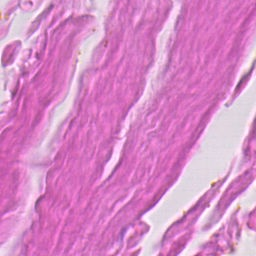

normal_122 label: 0 x: 50432 y: 5888


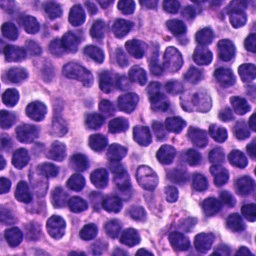

tumor_080 label: 1 x: 17152 y: 16640


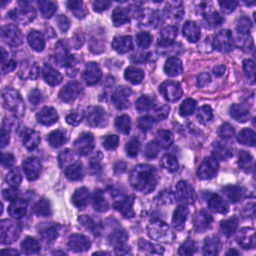

tumor_099 label: 1 x: 52992 y: 8704


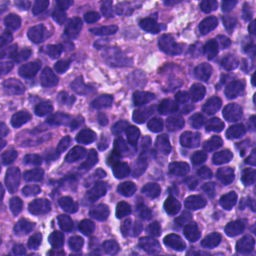

normal_094 label: 0 x: 56064 y: 70912


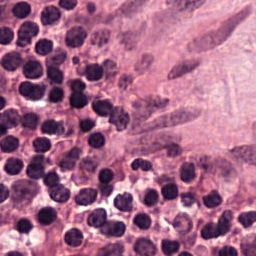

normal_074 label: 0 x: 55552 y: 77312


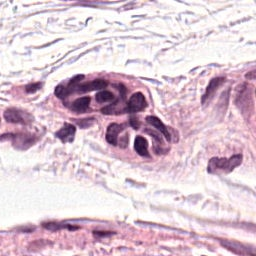

tumor_082 label: 1 x: 141312 y: 7424


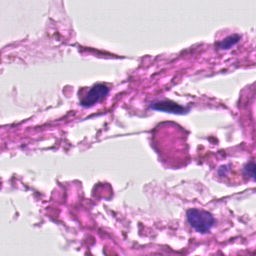

normal_107 label: 0 x: 24832 y: 11264


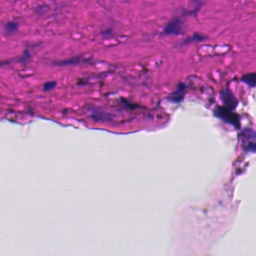

normal_146 label: 0 x: 47616 y: 9728


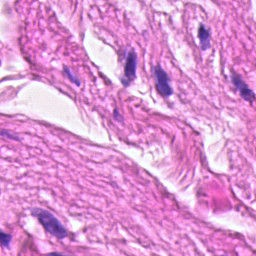

normal_145 label: 0 x: 82944 y: 1280


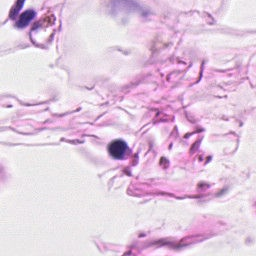

normal_144 label: 0 x: 30208 y: 96000


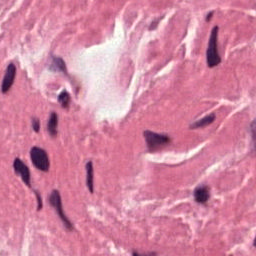

tumor_078 label: 1 x: 37888 y: 4352


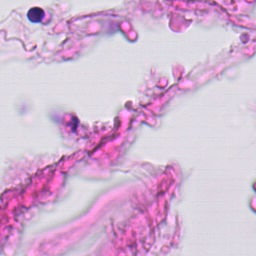

In [9]:
# === Cellule 10 : contrôle visuel de quelques patchs ===

from IPython.display import display

print("=== Sample de 12 patchs ===")
sample = df.sample(min(12, len(df)), random_state=0)

for _, row in sample.iterrows():
    print(row["wsi_id"], "label:", row["label"], "x:", row["x"], "y:", row["y"])
    img = Image.open(row["patch_path"])
    display(img)


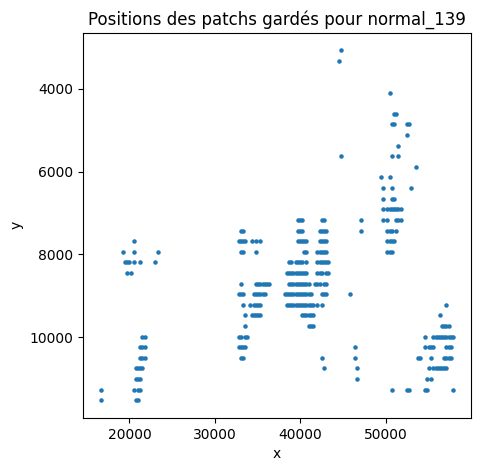

In [10]:
# === Cellule 11 : scatter des positions d'une WSI ===

if len(df) > 0:
    example_wsi = df['wsi_id'].sample(1, random_state=1).item()
    sub = df[df['wsi_id'] == example_wsi]

    plt.figure(figsize=(5,5))
    plt.scatter(sub['x'], sub['y'], s=5)
    plt.gca().invert_yaxis()
    plt.title(f"Positions des patchs gardés pour {example_wsi}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()
else:
    print("DataFrame vide, pas de scatter possible.")


=== Sample de 12 patchs ===
tumor_094 label: 1 x: 33792 y: 11520


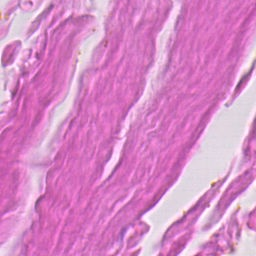

normal_122 label: 0 x: 50432 y: 5888


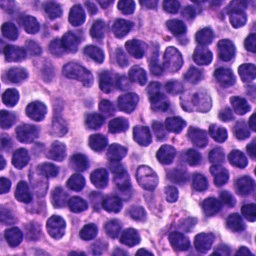

tumor_080 label: 1 x: 17152 y: 16640


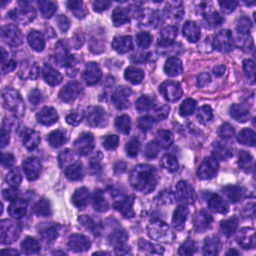

tumor_099 label: 1 x: 52992 y: 8704


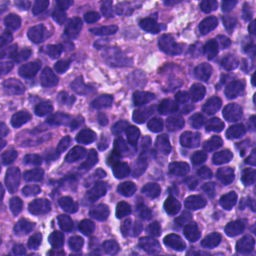

normal_094 label: 0 x: 56064 y: 70912


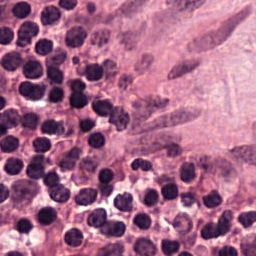

normal_074 label: 0 x: 55552 y: 77312


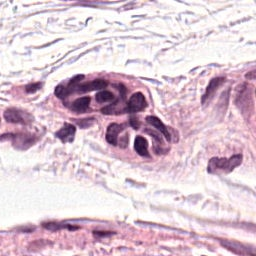

tumor_082 label: 1 x: 141312 y: 7424


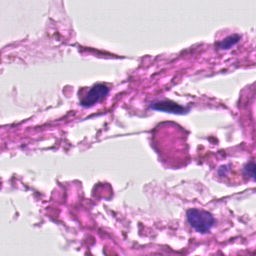

normal_107 label: 0 x: 24832 y: 11264


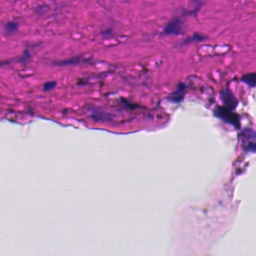

normal_146 label: 0 x: 47616 y: 9728


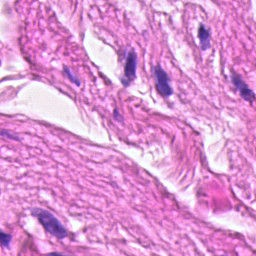

normal_145 label: 0 x: 82944 y: 1280


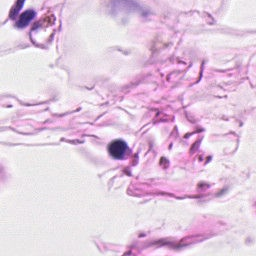

normal_144 label: 0 x: 30208 y: 96000


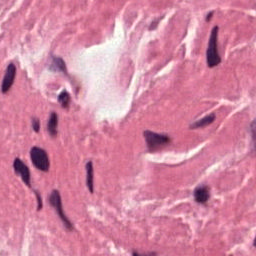

tumor_078 label: 1 x: 37888 y: 4352


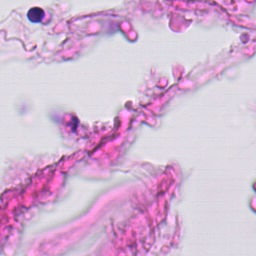

In [11]:
from IPython.display import display

print("=== Sample de 12 patchs ===")
sample = df.sample(12, random_state=0)

for _, row in sample.iterrows():
    print(row["wsi_id"], "label:", row["label"], "x:", row["x"], "y:", row["y"])
    img = Image.open(row["patch_path"])
    display(img)


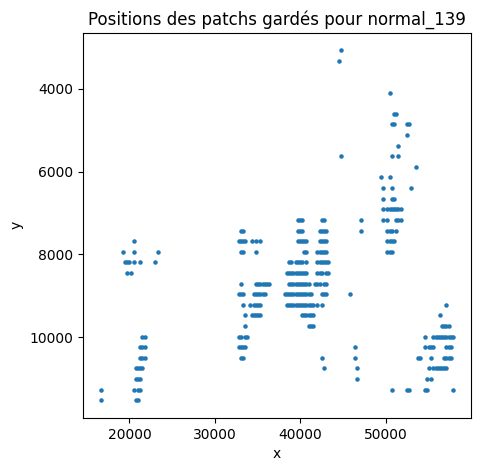

In [12]:
example_wsi = df['wsi_id'].sample(1, random_state=1).item()
sub = df[df['wsi_id'] == example_wsi]

plt.figure(figsize=(5,5))
plt.scatter(sub['x'], sub['y'], s=5)
plt.gca().invert_yaxis()
plt.title(f"Positions des patchs gardés pour {example_wsi}")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [13]:
import os

print("Contenu du dossier /kaggle/working :")
print(os.listdir("/kaggle/working"))

print("\nLe CSV existe-t-il ?")
print(os.path.exists("/kaggle/working/patches_metadata.csv"))


Contenu du dossier /kaggle/working :
['patches', '__notebook__.ipynb', 'patches_metadata.csv']

Le CSV existe-t-il ?
True
